In [1]:
import requests
from bs4 import BeautifulSoup

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url = "https://www.worldometers.info/coronavirus/"

response = requests.get(url)

print(response.status_code)

200


In [3]:
soup = BeautifulSoup(response.text, "html.parser")

print(soup.title.text)

COVID - Coronavirus Statistics - Worldometer


In [4]:
tables = soup.find_all("table")

print("Number of tables:", len(tables))

Number of tables: 3


In [5]:
table = soup.find("table", id="main_table_countries_today")

print(table is not None)

True


In [6]:
headers = []

for th in table.find_all("th"):
    headers.append(th.get_text(strip=True))

print(headers)

['#', 'Country,Other', 'TotalCases', 'NewCases', 'TotalDeaths', 'NewDeaths', 'TotalRecovered', 'NewRecovered', 'ActiveCases', 'Serious,Critical', 'Tot\xa0Cases/1M pop', 'Deaths/1M pop', 'TotalTests', 'Tests/1M pop', 'Population', 'Continent', '1 Caseevery X ppl', '1 Deathevery X ppl', '1 Testevery X ppl', 'New Cases/1M pop', 'New Deaths/1M pop', 'Active Cases/1M pop']


In [7]:
data = []

rows = table.find_all("tr")

for row in rows[1:]:
    cells = row.find_all("td")
    
    if cells:
        row_data = [cell.get_text(strip=True) for cell in cells]
        data.append(row_data)

print("Number of rows:", len(data))

Number of rows: 247


In [8]:
for row in data[:5]:
    print(row)

['', 'North America', '131,889,132', '', '1,695,941', '', '127,665,129', '+350', '2,528,062', '6,095', '', '', '', '', '', 'North America', '', '', '', '', '', '']
['', 'Asia', '221,500,265', '', '1,553,662', '', '205,673,091', '', '14,273,512', '14,733', '', '', '', '', '', 'Asia', '', '', '', '', '', '']
['', 'Europe', '253,406,198', '', '2,101,824', '', '248,754,104', '+474', '2,550,270', '4,453', '', '', '', '', '', 'Europe', '', '', '', '', '', '']
['', 'South America', '70,200,879', '', '1,367,332', '', '66,683,585', '', '2,149,962', '8,953', '', '', '', '', '', 'South America', '', '', '', '', '', '']
['', 'Oceania', '14,895,771', '', '33,015', '', '14,752,388', '', '110,368', '31', '', '', '', '', '', 'Australia/Oceania', '', '', '', '', '', '']


In [9]:
df = pd.DataFrame(data, columns=headers)

df.head()

,#,"Country,Other",TotalCases,NewCases,TotalDeaths,NewDeaths,TotalRecovered,NewRecovered,ActiveCases,"Serious,Critical",...,TotalTests,Tests/1M pop,Population,Continent,1 Caseevery X ppl,1 Deathevery X ppl,1 Testevery X ppl,New Cases/1M pop,New Deaths/1M pop,Active Cases/1M pop
0,,North America,"131,889,132",,"1,695,941",,"127,665,129",+350,"2,528,062","6,095",...,,,,North America,,,,,,
1,,Asia,"221,500,265",,"1,553,662",,"205,673,091",,"14,273,512","14,733",...,,,,Asia,,,,,,
2,,Europe,"253,406,198",,"2,101,824",,"248,754,104",+474,"2,550,270","4,453",...,,,,Europe,,,,,,
3,,South America,"70,200,879",,"1,367,332",,"66,683,585",,"2,149,962","8,953",...,,,,South America,,,,,,
4,,Oceania,"14,895,771",,"33,015",,"14,752,388",,"110,368",31,...,,,,Australia/Oceania,,,,,,


In [10]:
df.shape

(247, 22)

In [11]:
df.columns

Index(['#', 'Country,Other', 'TotalCases', 'NewCases', 'TotalDeaths',
       'NewDeaths', 'TotalRecovered', 'NewRecovered', 'ActiveCases',
       'Serious,Critical', 'Tot Cases/1M pop', 'Deaths/1M pop', 'TotalTests',
       'Tests/1M pop', 'Population', 'Continent', '1 Caseevery X ppl',
       '1 Deathevery X ppl', '1 Testevery X ppl', 'New Cases/1M pop',
       'New Deaths/1M pop', 'Active Cases/1M pop'],
      dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   #                    247 non-null    object
 1   Country,Other        247 non-null    object
 2   TotalCases           247 non-null    object
 3   NewCases             247 non-null    object
 4   TotalDeaths          247 non-null    object
 5   NewDeaths            247 non-null    object
 6   TotalRecovered       247 non-null    object
 7   NewRecovered         247 non-null    object
 8   ActiveCases          247 non-null    object
 9   Serious,Critical     247 non-null    object
 10  Tot Cases/1M pop     247 non-null    object
 11  Deaths/1M pop        247 non-null    object
 12  TotalTests           247 non-null    object
 13  Tests/1M pop         247 non-null    object
 14  Population           247 non-null    object
 15  Continent            247 non-null    object
 16  1 Caseev

In [13]:
df.head()

,#,"Country,Other",TotalCases,NewCases,TotalDeaths,NewDeaths,TotalRecovered,NewRecovered,ActiveCases,"Serious,Critical",...,TotalTests,Tests/1M pop,Population,Continent,1 Caseevery X ppl,1 Deathevery X ppl,1 Testevery X ppl,New Cases/1M pop,New Deaths/1M pop,Active Cases/1M pop
0,,North America,"131,889,132",,"1,695,941",,"127,665,129",+350,"2,528,062","6,095",...,,,,North America,,,,,,
1,,Asia,"221,500,265",,"1,553,662",,"205,673,091",,"14,273,512","14,733",...,,,,Asia,,,,,,
2,,Europe,"253,406,198",,"2,101,824",,"248,754,104",+474,"2,550,270","4,453",...,,,,Europe,,,,,,
3,,South America,"70,200,879",,"1,367,332",,"66,683,585",,"2,149,962","8,953",...,,,,South America,,,,,,
4,,Oceania,"14,895,771",,"33,015",,"14,752,388",,"110,368",31,...,,,,Australia/Oceania,,,,,,


In [18]:
df = pd.DataFrame(data, columns=headers)

df.head()

,#,"Country,Other",TotalCases,NewCases,TotalDeaths,NewDeaths,TotalRecovered,NewRecovered,ActiveCases,"Serious,Critical",...,TotalTests,Tests/1M pop,Population,Continent,1 Caseevery X ppl,1 Deathevery X ppl,1 Testevery X ppl,New Cases/1M pop,New Deaths/1M pop,Active Cases/1M pop
0,,North America,"131,889,132",,"1,695,941",,"127,665,129",+350,"2,528,062","6,095",...,,,,North America,,,,,,
1,,Asia,"221,500,265",,"1,553,662",,"205,673,091",,"14,273,512","14,733",...,,,,Asia,,,,,,
2,,Europe,"253,406,198",,"2,101,824",,"248,754,104",+474,"2,550,270","4,453",...,,,,Europe,,,,,,
3,,South America,"70,200,879",,"1,367,332",,"66,683,585",,"2,149,962","8,953",...,,,,South America,,,,,,
4,,Oceania,"14,895,771",,"33,015",,"14,752,388",,"110,368",31,...,,,,Australia/Oceania,,,,,,


In [19]:
print(df.columns.tolist())

['#', 'Country,Other', 'TotalCases', 'NewCases', 'TotalDeaths', 'NewDeaths', 'TotalRecovered', 'NewRecovered', 'ActiveCases', 'Serious,Critical', 'Tot\xa0Cases/1M pop', 'Deaths/1M pop', 'TotalTests', 'Tests/1M pop', 'Population', 'Continent', '1 Caseevery X ppl', '1 Deathevery X ppl', '1 Testevery X ppl', 'New Cases/1M pop', 'New Deaths/1M pop', 'Active Cases/1M pop']


In [20]:
df = df[
    [
        "Country,Other",
        "TotalCases",
        "TotalDeaths",
        "TotalRecovered",
        "ActiveCases",
        "Serious,Critical",
        "Tot\xa0Cases/1M pop",
        "Deaths/1M pop",
        "TotalTests",
        "Tests/1M pop",
        "Population",
        "Continent"
    ]
]

df.head()

,"Country,Other",TotalCases,TotalDeaths,TotalRecovered,ActiveCases,"Serious,Critical",Tot Cases/1M pop,Deaths/1M pop,TotalTests,Tests/1M pop,Population,Continent
0,North America,"131,889,132","1,695,941","127,665,129","2,528,062","6,095",,,,,,North America
1,Asia,"221,500,265","1,553,662","205,673,091","14,273,512","14,733",,,,,,Asia
2,Europe,"253,406,198","2,101,824","248,754,104","2,550,270","4,453",,,,,,Europe
3,South America,"70,200,879","1,367,332","66,683,585","2,149,962","8,953",,,,,,South America
4,Oceania,"14,895,771","33,015","14,752,388","110,368",31,,,,,,Australia/Oceania


In [21]:
df = df.rename(columns={
    "Country,Other": "Country",
    "TotalCases": "Total Cases",
    "TotalDeaths": "Total Deaths",
    "TotalRecovered": "Total Recovered",
    "ActiveCases": "Active Cases",
    "Serious,Critical": "Serious Critical",
    "Tot\xa0Cases/1M pop": "Cases/1M Pop",
    "Deaths/1M pop": "Deaths/1M Pop",
    "TotalTests": "Total Tests",
    "Tests/1M pop": "Tests/1M Pop",
    "Population": "Population",
    "Continent": "Continent"
})

df.head()

,Country,Total Cases,Total Deaths,Total Recovered,Active Cases,Serious Critical,Cases/1M Pop,Deaths/1M Pop,Total Tests,Tests/1M Pop,Population,Continent
0,North America,"131,889,132","1,695,941","127,665,129","2,528,062","6,095",,,,,,North America
1,Asia,"221,500,265","1,553,662","205,673,091","14,273,512","14,733",,,,,,Asia
2,Europe,"253,406,198","2,101,824","248,754,104","2,550,270","4,453",,,,,,Europe
3,South America,"70,200,879","1,367,332","66,683,585","2,149,962","8,953",,,,,,South America
4,Oceania,"14,895,771","33,015","14,752,388","110,368",31,,,,,,Australia/Oceania


In [22]:
print(df.columns.tolist())

['Country', 'Total Cases', 'Total Deaths', 'Total Recovered', 'Active Cases', 'Serious Critical', 'Cases/1M Pop', 'Deaths/1M Pop', 'Total Tests', 'Tests/1M Pop', 'Population', 'Continent']


In [23]:
# Remove rows with missing country names
df = df.dropna(subset=["Country"])

# Remove non-country rows
df = df[
    ~df["Country"].isin([
        "World",
        "North America",
        "Asia",
        "Europe",
        "South America",
        "Africa",
        "Oceania",
        "Australia/Oceania"
    ])
]

df.head()

,Country,Total Cases,Total Deaths,Total Recovered,Active Cases,Serious Critical,Cases/1M Pop,Deaths/1M Pop,Total Tests,Tests/1M Pop,Population,Continent
6,,721,15,706,0,0,,,,,,
8,USA,"111,820,082","1,219,487","109,814,428","786,167",940,"333,985","3,642","1,186,851,502","3,544,901","334,805,269",North America
9,India,"45,035,393","533,570",N/A,N/A,N/A,"32,016",379,"935,879,495","665,334","1,406,631,776",Asia
10,France,"40,138,560","167,642","39,970,918",0,,"612,013","2,556","271,490,188","4,139,547","65,584,518",Europe
11,Germany,"38,828,995","183,027","38,240,600","405,368",N/A,"462,891","2,182","122,332,384","1,458,359","83,883,596",Europe


In [24]:
print("Number of countries:", len(df))

Number of countries: 240


In [25]:
numeric_columns = [
    "Total Cases",
    "Total Deaths",
    "Total Recovered",
    "Active Cases",
    "Serious Critical",
    "Cases/1M Pop",
    "Deaths/1M Pop",
    "Total Tests",
    "Tests/1M Pop",
    "Population"
]

for column in numeric_columns:
    df[column] = (
        df[column]
        .str.replace(",", "", regex=False)
        .str.replace("+", "", regex=False)
        .replace(["N/A", "", "-", "nan"], np.nan)
        .astype(float)
    )

df.head()

,Country,Total Cases,Total Deaths,Total Recovered,Active Cases,Serious Critical,Cases/1M Pop,Deaths/1M Pop,Total Tests,Tests/1M Pop,Population,Continent
6,,721.0,15.0,706.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,
8,USA,111820082.0,1219487.0,109814428.0,786167.0,940.0,333985.0,3642.0,1.186852e+09,3544901.0,3.348053e+08,North America
9,India,45035393.0,533570.0,NaN,NaN,NaN,32016.0,379.0,9.358795e+08,665334.0,1.406632e+09,Asia
10,France,40138560.0,167642.0,39970918.0,0.0,NaN,612013.0,2556.0,2.714902e+08,4139547.0,6.558452e+07,Europe
11,Germany,38828995.0,183027.0,38240600.0,405368.0,NaN,462891.0,2182.0,1.223324e+08,1458359.0,8.388360e+07,Europe


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 240 entries, 6 to 246
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Country           240 non-null    object 
 1   Total Cases       240 non-null    float64
 2   Total Deaths      235 non-null    float64
 3   Total Recovered   192 non-null    float64
 4   Active Cases      193 non-null    float64
 5   Serious Critical  61 non-null     float64
 6   Cases/1M Pop      230 non-null    float64
 7   Deaths/1M Pop     225 non-null    float64
 8   Total Tests       213 non-null    float64
 9   Tests/1M Pop      213 non-null    float64
 10  Population        229 non-null    float64
 11  Continent         240 non-null    object 
dtypes: float64(10), object(2)
memory usage: 24.4+ KB


In [27]:
df["Death Rate (%)"] = np.where(
    df["Total Cases"] > 0,
    df["Total Deaths"] / df["Total Cases"] * 100,
    0
)

df["Recovery Rate (%)"] = np.where(
    df["Total Cases"] > 0,
    df["Total Recovered"] / df["Total Cases"] * 100,
    0
)

df["Active Rate (%)"] = np.where(
    df["Total Cases"] > 0,
    df["Active Cases"] / df["Total Cases"] * 100,
    0
)

df.head()

,Country,Total Cases,Total Deaths,Total Recovered,Active Cases,Serious Critical,Cases/1M Pop,Deaths/1M Pop,Total Tests,Tests/1M Pop,Population,Continent,Death Rate (%),Recovery Rate (%),Active Rate (%)
6,,721.0,15.0,706.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,,2.080444,97.919556,0.000000
8,USA,111820082.0,1219487.0,109814428.0,786167.0,940.0,333985.0,3642.0,1.186852e+09,3544901.0,3.348053e+08,North America,1.090580,98.206356,0.703064
9,India,45035393.0,533570.0,NaN,NaN,NaN,32016.0,379.0,9.358795e+08,665334.0,1.406632e+09,Asia,1.184779,NaN,NaN
10,France,40138560.0,167642.0,39970918.0,0.0,NaN,612013.0,2556.0,2.714902e+08,4139547.0,6.558452e+07,Europe,0.417658,99.582342,0.000000
11,Germany,38828995.0,183027.0,38240600.0,405368.0,NaN,462891.0,2182.0,1.223324e+08,1458359.0,8.388360e+07,Europe,0.471367,98.484650,1.043983


In [28]:
top_cases = df.nlargest(10, "Total Cases")

top_cases[["Country", "Total Cases"]]

,Country,Total Cases
246,Total:,704753890.0
241,Total:,253406198.0
240,Total:,221500265.0
239,Total:,131889132.0
8,USA,111820082.0
242,Total:,70200879.0
9,India,45035393.0
10,France,40138560.0
11,Germany,38828995.0
12,Brazil,38743918.0


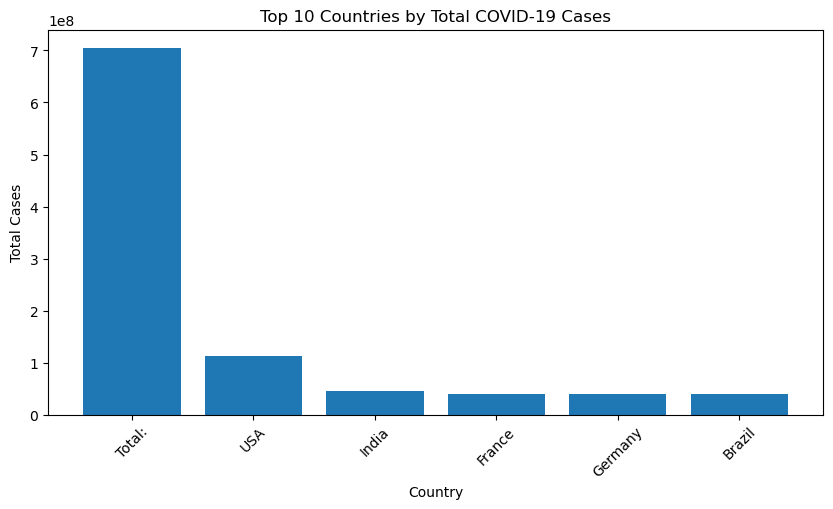

In [29]:
plt.figure(figsize=(10, 5))

plt.bar(top_cases["Country"], top_cases["Total Cases"])

plt.title("Top 10 Countries by Total COVID-19 Cases")
plt.xlabel("Country")
plt.ylabel("Total Cases")
plt.xticks(rotation=45)

plt.show()

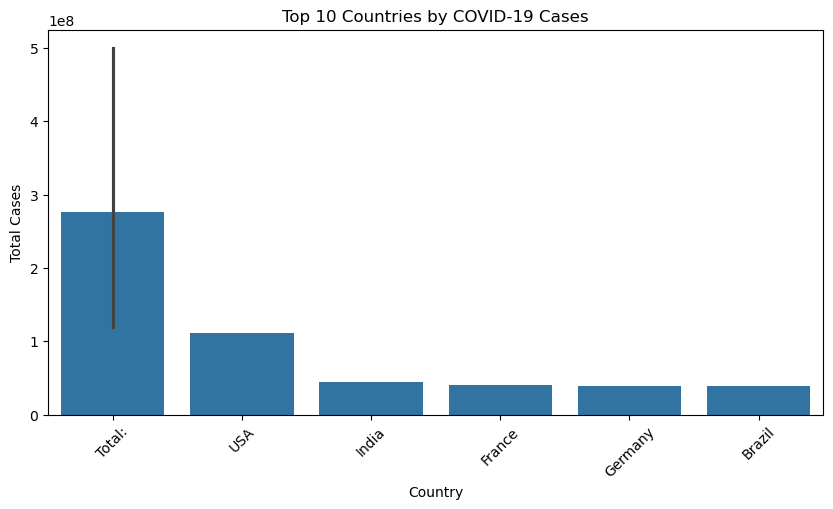

In [30]:
plt.figure(figsize=(10, 5))

sns.barplot(data=top_cases, x="Country", y="Total Cases")

plt.title("Top 10 Countries by COVID-19 Cases")
plt.xticks(rotation=45)

plt.show()

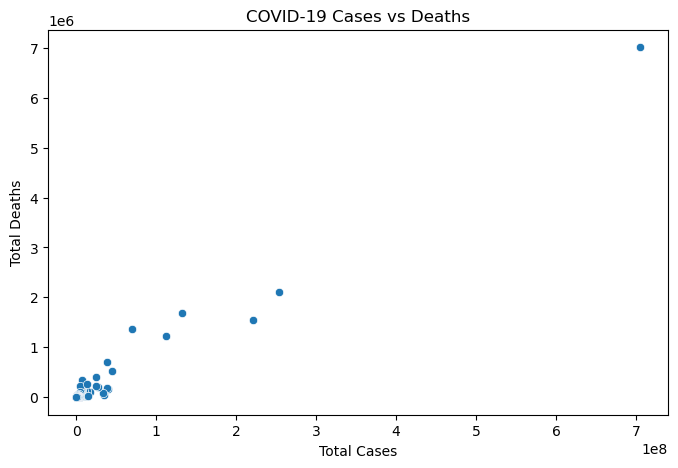

In [31]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="Total Cases", y="Total Deaths")

plt.title("COVID-19 Cases vs Deaths")
plt.xlabel("Total Cases")
plt.ylabel("Total Deaths")

plt.show()

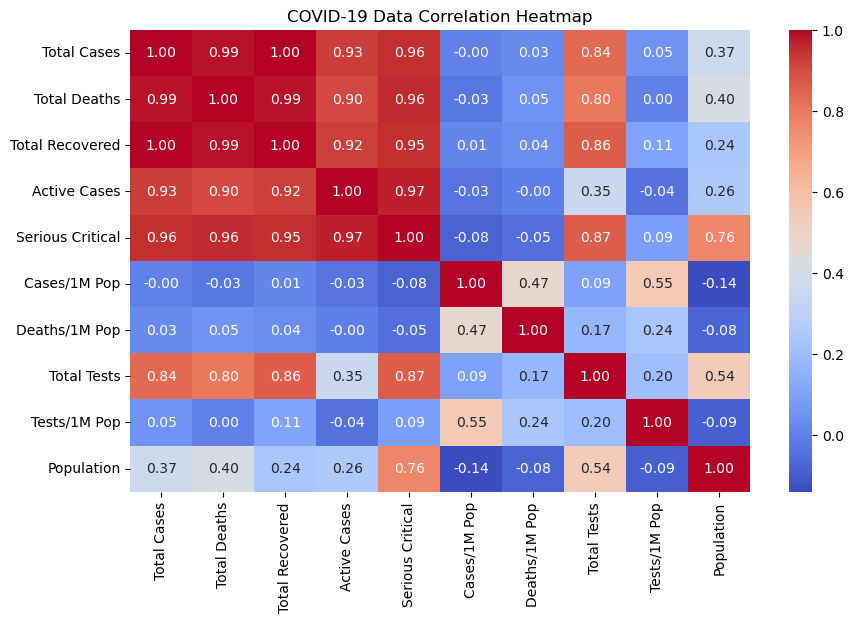

In [32]:
plt.figure(figsize=(10, 6))

corr = df[numeric_columns].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("COVID-19 Data Correlation Heatmap")
plt.show()

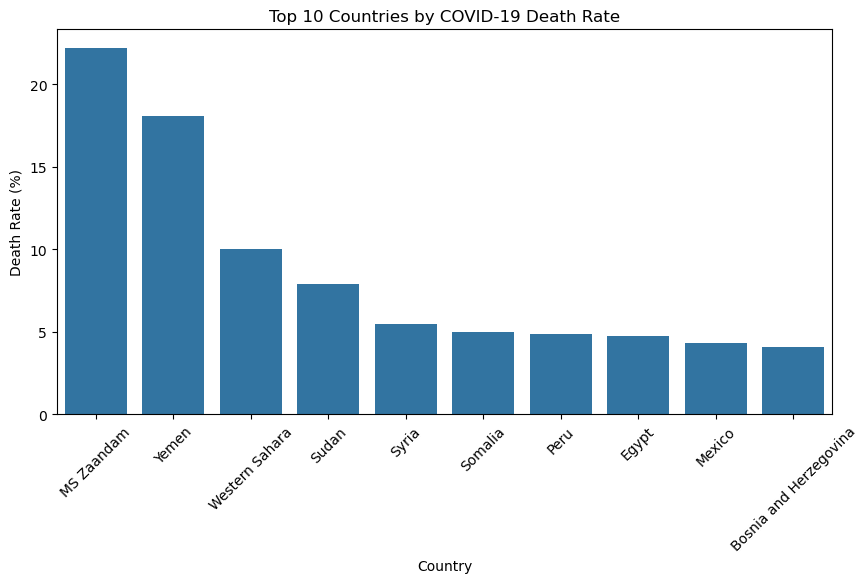

In [33]:
top_death_rate = df.nlargest(10, "Death Rate (%)")

plt.figure(figsize=(10, 5))

sns.barplot(data=top_death_rate, x="Country", y="Death Rate (%)")

plt.title("Top 10 Countries by COVID-19 Death Rate")
plt.xlabel("Country")
plt.ylabel("Death Rate (%)")
plt.xticks(rotation=45)

plt.show()

In [34]:
df.to_csv("covid_cleaned_data.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [35]:
# ===================== PROJECT SUMMARY =====================

# 1. Imported required Python libraries:
#    - Requests
#    - BeautifulSoup
#    - Pandas
#    - NumPy
#    - Matplotlib
#    - Seaborn

# 2. Used BeautifulSoup to scrape COVID-19 data from Worldometer.

# 3. Extracted the COVID-19 country-wise table from the webpage.

# 4. Created a Pandas DataFrame from the extracted data.

# 5. Selected the important columns required for analysis.

# 6. Removed unnecessary rows such as World and continent-level data.

# 7. Cleaned the dataset and converted numerical columns into numeric data types.

# 8. Used NumPy to calculate:
#    - Death Rate
#    - Recovery Rate
#    - Active Case Rate

# 9. Used Pandas to find the Top 10 countries by total COVID-19 cases.

# 10. Created visualizations using Matplotlib.

# 11. Created visualizations using Seaborn:
#     - Bar Plot
#     - Scatter Plot
#     - Correlation Heatmap

# 12. Analyzed the relationship between COVID-19 cases and deaths.

# 13. Compared countries based on COVID-19 death rate.

# 14. Saved the final cleaned dataset as a CSV file.

# ===================== END OF PROJECT =====================